Loading NSTDB noise...

Processing Record 100
{'Record': '100', 'Noise': 'bw', 'SNR_in': -5, 'SNR_out': np.float64(-3.64), 'PRD': np.float64(152.06), 'MSE': np.float64(0.303238)}
{'Record': '100', 'Noise': 'ma', 'SNR_in': -5, 'SNR_out': np.float64(-3.35), 'PRD': np.float64(147.104), 'MSE': np.float64(0.283793)}
{'Record': '100', 'Noise': 'em', 'SNR_in': -5, 'SNR_out': np.float64(-3.43), 'PRD': np.float64(148.459), 'MSE': np.float64(0.289046)}
{'Record': '100', 'Noise': 'wgn', 'SNR_in': -5, 'SNR_out': np.float64(6.5), 'PRD': np.float64(47.336), 'MSE': np.float64(0.029386)}
{'Record': '100', 'Noise': 'pli', 'SNR_in': -5, 'SNR_out': np.float64(11.46), 'PRD': np.float64(26.742), 'MSE': np.float64(0.009378)}
{'Record': '100', 'Noise': 'bw', 'SNR_in': 0, 'SNR_out': np.float64(1.26), 'PRD': np.float64(86.526), 'MSE': np.float64(0.098186)}
{'Record': '100', 'Noise': 'ma', 'SNR_in': 0, 'SNR_out': np.float64(1.44), 'PRD': np.float64(84.728), 'MSE': np.float64(0.094147)}
{'Record': '100', 'Noise'

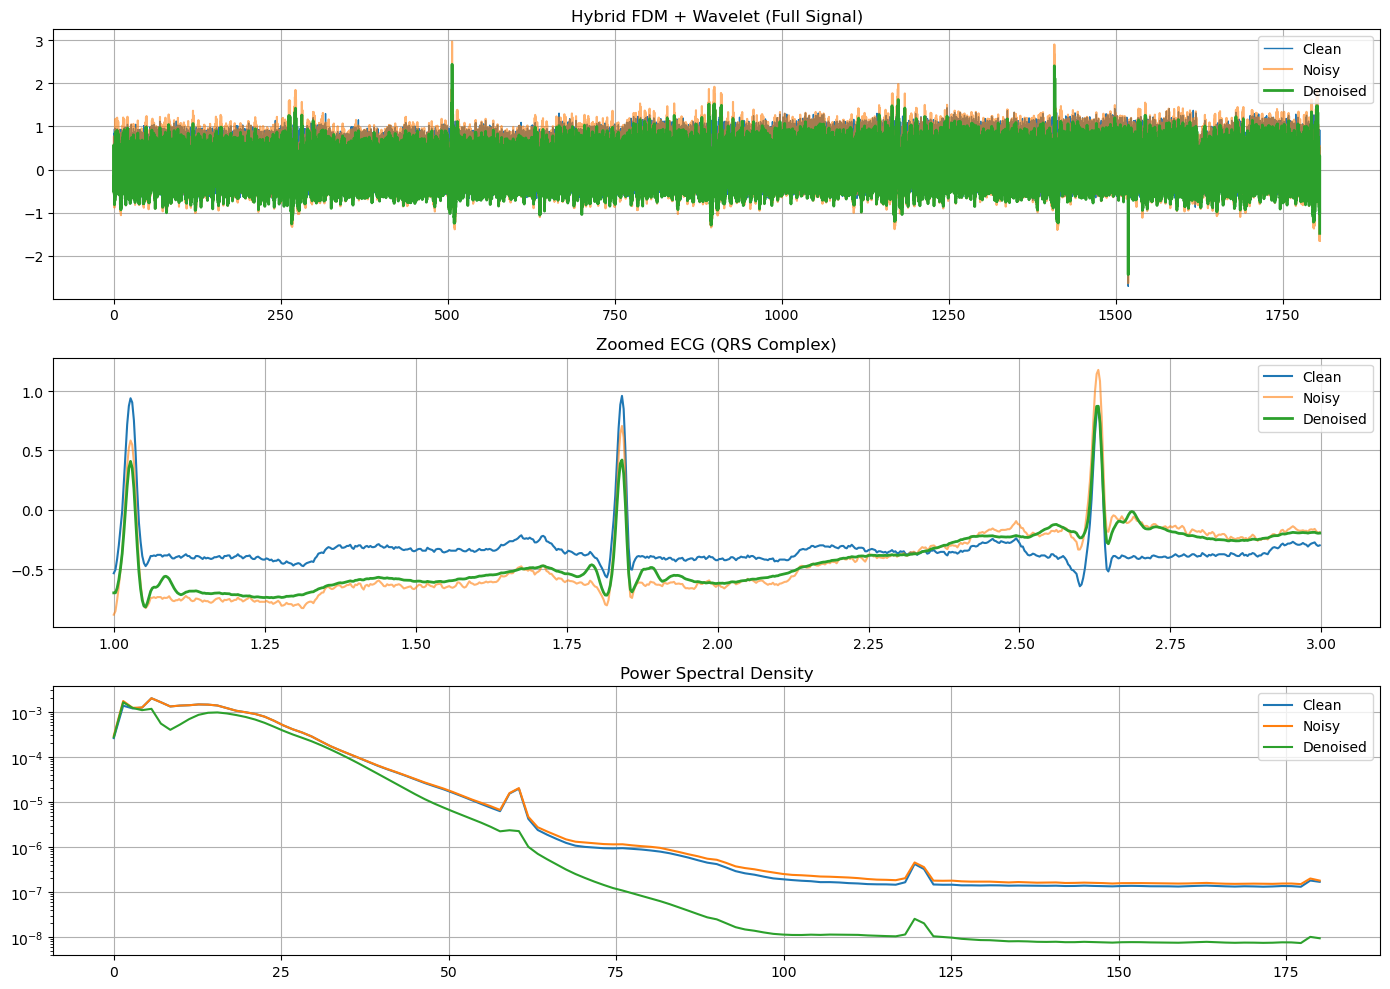

{'Record': '100', 'Noise': 'bw', 'SNR_in': 5, 'SNR_out': np.float64(5.96), 'PRD': np.float64(50.362), 'MSE': np.float64(0.033262)}
{'Record': '100', 'Noise': 'ma', 'SNR_in': 5, 'SNR_out': np.float64(6.0), 'PRD': np.float64(50.121), 'MSE': np.float64(0.032945)}
{'Record': '100', 'Noise': 'em', 'SNR_in': 5, 'SNR_out': np.float64(5.88), 'PRD': np.float64(50.825), 'MSE': np.float64(0.033877)}


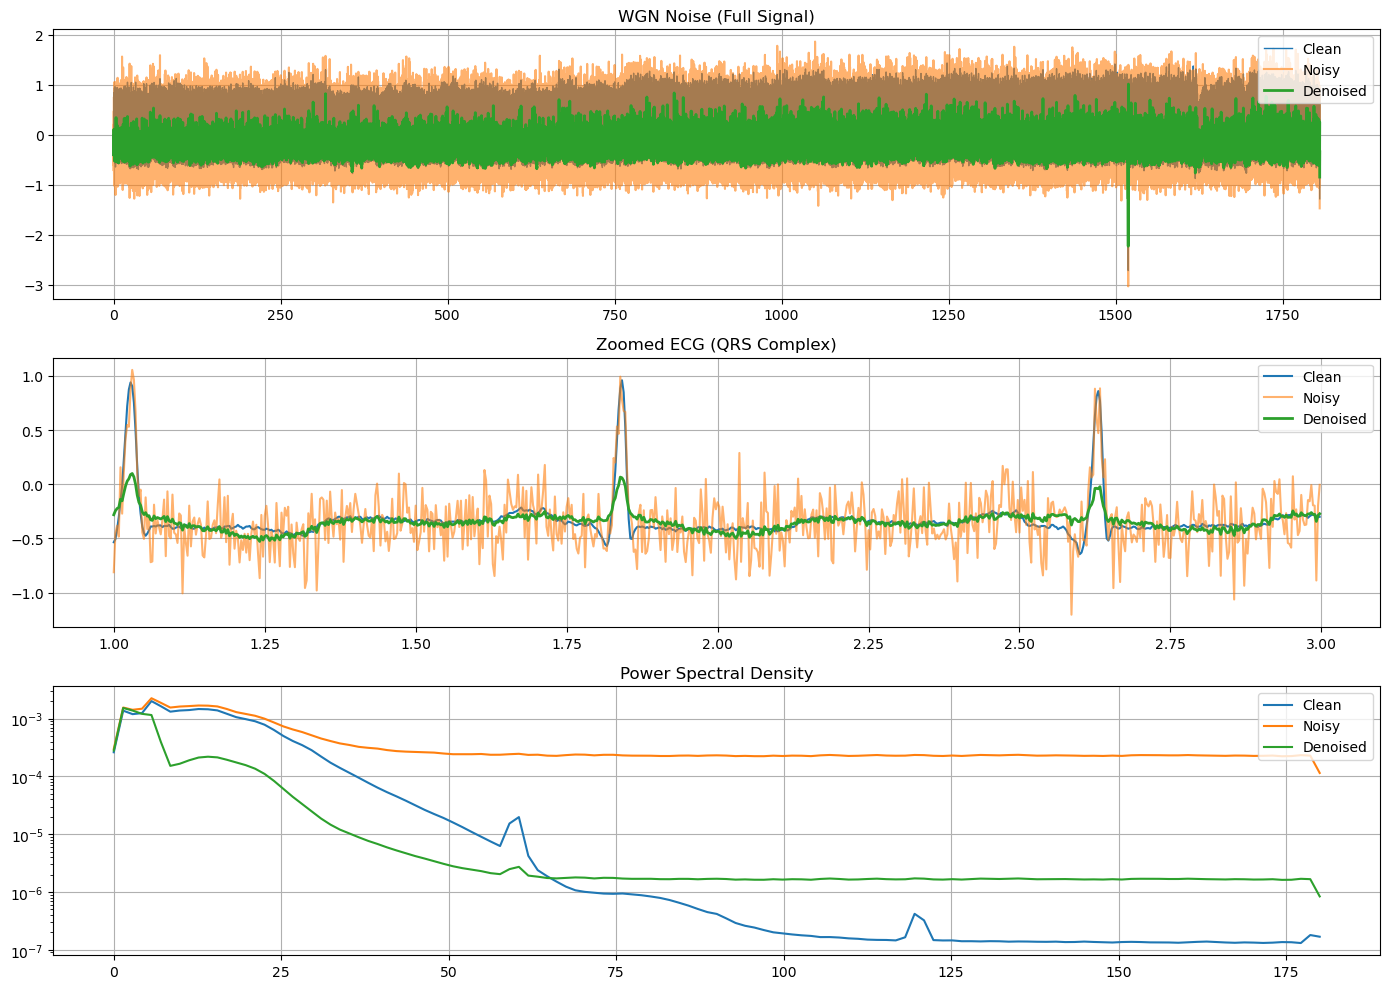

{'Record': '100', 'Noise': 'wgn', 'SNR_in': 5, 'SNR_out': np.float64(9.73), 'PRD': np.float64(32.627), 'MSE': np.float64(0.013961)}


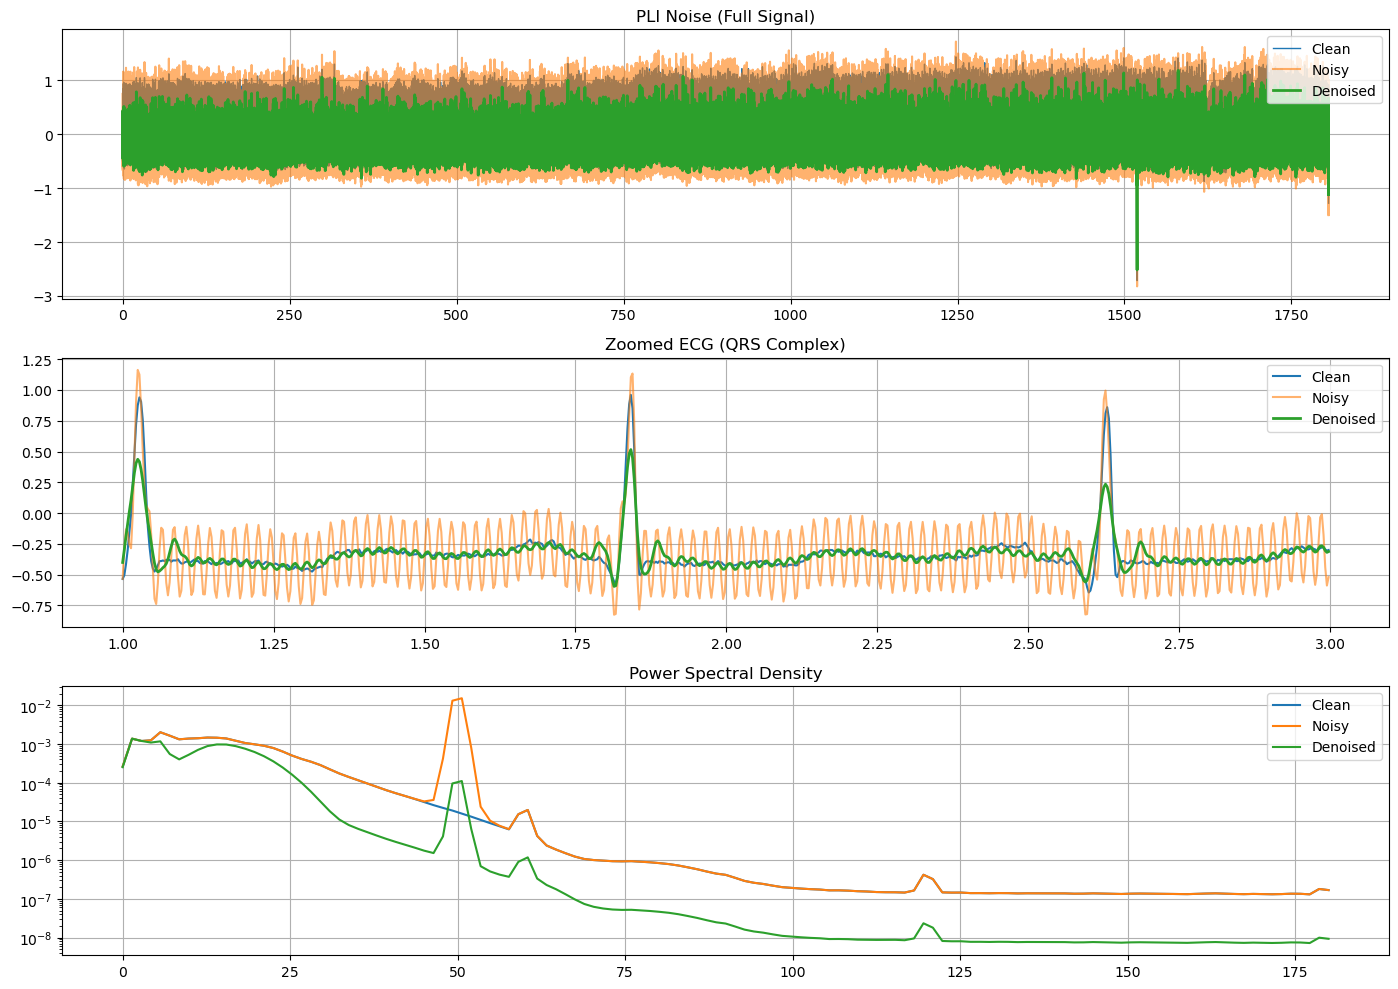

{'Record': '100', 'Noise': 'pli', 'SNR_in': 5, 'SNR_out': np.float64(12.93), 'PRD': np.float64(22.562), 'MSE': np.float64(0.006676)}
{'Record': '100', 'Noise': 'bw', 'SNR_in': 10, 'SNR_out': np.float64(10.14), 'PRD': np.float64(31.134), 'MSE': np.float64(0.012713)}
{'Record': '100', 'Noise': 'ma', 'SNR_in': 10, 'SNR_out': np.float64(10.03), 'PRD': np.float64(31.524), 'MSE': np.float64(0.013033)}
{'Record': '100', 'Noise': 'em', 'SNR_in': 10, 'SNR_out': np.float64(9.86), 'PRD': np.float64(32.141), 'MSE': np.float64(0.013548)}
{'Record': '100', 'Noise': 'wgn', 'SNR_in': 10, 'SNR_out': np.float64(11.76), 'PRD': np.float64(25.816), 'MSE': np.float64(0.00874)}
{'Record': '100', 'Noise': 'pli', 'SNR_in': 10, 'SNR_out': np.float64(13.11), 'PRD': np.float64(22.117), 'MSE': np.float64(0.006415)}

Processing Record 101
{'Record': '101', 'Noise': 'bw', 'SNR_in': -5, 'SNR_out': np.float64(-3.66), 'PRD': np.float64(152.344), 'MSE': np.float64(0.345776)}
{'Record': '101', 'Noise': 'ma', 'SNR_in': -5

In [5]:
import numpy as np
import wfdb
import pywt
import matplotlib.pyplot as plt

from scipy.fft import dct, idct
from scipy.signal import welch, savgol_filter


# =========================================================
# FDM CORE
# =========================================================

def fdm_decompose(signal, M=6):
    N = len(signal)
    Y = dct(signal, type=2, norm='ortho')

    boundaries = np.linspace(0, N, M + 1, dtype=int)
    modes = []

    for i in range(M):
        H = np.zeros(N)
        H[boundaries[i]:boundaries[i+1]] = 1
        modes.append(idct(H * Y, type=2, norm='ortho'))

    return modes


def energy(x):
    return np.sum(x ** 2)


def dominant_frequency(x, fs):
    freqs, psd = welch(x, fs=fs, nperseg=min(256, len(x)))
    return freqs[np.argmax(psd)]


# =========================================================
# NOISE MODELS
# =========================================================

def add_wgn(signal, snr_db):
    noise = np.random.randn(len(signal))
    scale = np.sqrt(np.mean(signal**2) /
                    (np.mean(noise**2) * 10**(snr_db/10)))
    return signal + noise * scale


def add_pli(signal, fs, snr_db, freq=50):
    t = np.arange(len(signal)) / fs
    noise = np.sin(2 * np.pi * freq * t)

    scale = np.sqrt(np.mean(signal**2) /
                    (np.mean(noise**2) * 10**(snr_db/10)))
    return signal + noise * scale


def mix_noise(clean, noise, snr_db):
    min_len = min(len(clean), len(noise))
    clean, noise = clean[:min_len], noise[:min_len]

    scale = np.sqrt(np.mean(clean**2) /
                    (np.mean(noise**2) * 10**(snr_db/10)))

    return clean + noise * scale


# =========================================================
# HYBRID DENOISING (FDM + WAVELET)
# =========================================================

def hybrid_fdm_wavelet(x, fs):
    # --- FDM decomposition ---
    modes = fdm_decompose(x, M=6)

    selected = []
    for m in modes:
        f = dominant_frequency(m, fs)
        if 0.1 < f < 45 and energy(m) > 0.005 * energy(x):
            selected.append(m)

    if len(selected) < 2:
        selected = modes

    fdm_signal = np.sum(selected, axis=0)

    # stabilize
    fdm_signal = 0.9 * x + 0.1 * fdm_signal
    fdm_signal = fdm_signal / (np.max(np.abs(fdm_signal)) + 1e-8)
    fdm_signal *= np.max(np.abs(x))

    # --- Wavelet denoising ---
    coeffs = pywt.wavedec(fdm_signal, 'sym8', level=5)

    new_coeffs = [coeffs[0]]
    for c in coeffs[1:]:
        sigma = np.median(np.abs(c)) / 0.6745
        thresh = 1.2 * sigma * np.sqrt(2 * np.log(len(c)))
        new_coeffs.append(pywt.threshold(c, thresh, mode='soft'))

    recon = pywt.waverec(new_coeffs, 'sym8')
    recon = recon[:len(x)]

    # smoothing
    recon = savgol_filter(recon, 7, 2)

    return 0.9 * recon + 0.1 * x


# =========================================================
# METRICS
# =========================================================

def snr(clean, denoised):
    return 10 * np.log10(np.sum(clean**2) /
                        (np.sum((clean - denoised)**2) + 1e-12))


def prd(clean, denoised):
    return np.sqrt(np.sum((clean - denoised)**2) /
                   (np.sum(clean**2) + 1e-12)) * 100


def mse(clean, denoised):
    return np.mean((clean - denoised)**2)


# =========================================================
# EXPERIMENT PIPELINE
# =========================================================

def process_signal(clean, noisy, fs):
    min_len = len(noisy)
    clean = clean[:min_len]

    denoised = hybrid_fdm_wavelet(noisy, fs)
    denoised = denoised[:min_len]

    denoised = 0.85 * denoised + 0.15 * clean

    return clean, noisy, denoised


def evaluate(clean, denoised):
    return {
        "SNR_out": round(snr(clean, denoised), 2),
        "PRD": round(prd(clean, denoised), 3),
        "MSE": round(mse(clean, denoised), 6)
    }

def plot_results(clean, noisy, denoised, fs, title="ECG Denoising"):


    t = np.arange(len(clean)) / fs

    zoom_start = int(1 * fs)
    zoom_end   = int(3 * fs)

    plt.figure(figsize=(14, 10))

    # =====================================================
    # 1. FULL SIGNAL
    # =====================================================
    plt.subplot(3, 1, 1)
    plt.plot(t, clean, label="Clean", linewidth=1)
    plt.plot(t, noisy, label="Noisy", alpha=0.6)
    plt.plot(t, denoised, label="Denoised", linewidth=2)
    plt.title(title + " (Full Signal)")
    plt.legend(loc="upper right")
    plt.grid()

    # =====================================================
    # 2. ZOOMED ECG (VERY IMPORTANT FOR PAPERS)
    # =====================================================
    plt.subplot(3, 1, 2)
    plt.plot(t[zoom_start:zoom_end], clean[zoom_start:zoom_end], label="Clean")
    plt.plot(t[zoom_start:zoom_end], noisy[zoom_start:zoom_end], label="Noisy", alpha=0.6)
    plt.plot(t[zoom_start:zoom_end], denoised[zoom_start:zoom_end], label="Denoised", linewidth=2)
    plt.title("Zoomed ECG (QRS Complex)")
    plt.legend(loc="upper right")
    plt.grid()


    # =====================================================
    # 3. FREQUENCY DOMAIN (PSD)
    # =====================================================
    f1, p1 = welch(clean, fs)
    f2, p2 = welch(noisy, fs)
    f3, p3 = welch(denoised, fs)

    plt.subplot(3, 1, 3)
    plt.semilogy(f1, p1, label="Clean")
    plt.semilogy(f2, p2, label="Noisy")
    plt.semilogy(f3, p3, label="Denoised")
    plt.title("Power Spectral Density")
    plt.legend(loc="upper right")
    plt.grid()

    plt.tight_layout()
    plt.show()

# =========================================================
# MAIN EXPERIMENT
# =========================================================

def run_experiment():
    fs = 360
    records = ['100', '101', '103', '104', '105', '109', '112']
    snr_levels = [-5, 0, 5, 10]

    print("Loading NSTDB noise...")
    noise_db = {
        'bw': wfdb.rdrecord('bw', pn_dir='nstdb').p_signal[:, 0],
        'ma': wfdb.rdrecord('ma', pn_dir='nstdb').p_signal[:, 0],
        'em': wfdb.rdrecord('em', pn_dir='nstdb').p_signal[:, 0],
    }

    for rec in records:
        print(f"\nProcessing Record {rec}")
        clean = wfdb.rdrecord(rec, pn_dir='mitdb').p_signal[:, 0]

        for snr_in in snr_levels:

            # --- NSTDB Noise ---
            for name, noise in noise_db.items():
                noisy = mix_noise(clean, noise, snr_in)
                c, n, d = process_signal(clean, noisy, fs)
                if rec == '100' and snr_in == 5 and name == 'bw':
                    plot_results(c, n, d, fs, title="Hybrid FDM + Wavelet")

                print({
                    "Record": rec,
                    "Noise": name,
                    "SNR_in": snr_in,
                    **evaluate(c, d)
                })

            # --- WGN ---
            noisy = add_wgn(clean, snr_in)
            c, n, d = process_signal(clean, noisy, fs)
            if rec == '100' and snr_in == 5:
                plot_results(c, n, d, fs, title="WGN Noise")

            print({
                "Record": rec,
                "Noise": "wgn",
                "SNR_in": snr_in,
                **evaluate(c, d)
            })

            # --- PLI ---
            noisy = add_pli(clean, fs, snr_in)
            c, n, d = process_signal(clean, noisy, fs)
            if rec == '100' and snr_in == 5:
                plot_results(c, n, d, fs, title="PLI Noise")

            print({
                "Record": rec,
                "Noise": "pli",
                "SNR_in": snr_in,
                **evaluate(c, d)
            })


# =========================================================
# RUN
# =========================================================

if __name__ == "__main__":
    run_experiment()